In [1]:
# https://www.kaggle.com/datasets/uciml/sms-spam-collection-dataset Datest LInk

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("spam.csv" , encoding='latin1') 

In [4]:
df.sample(9)

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
5287,ham,Hey ! Don't forget ... You are MINE ... For ME...,NaN,NaN,NaN
819,ham,\BOO BABE! U ENJOYIN YOURJOB? U SEEMED 2 B GET...,NaN,NaN,NaN
4622,ham,U need my presnts always bcz U cant mis love. ...,NaN,NaN,NaN
289,ham,"Dear,shall mail tonite.busy in the street,shal...",NaN,NaN,NaN
1454,ham,Can Ì_ all decide faster cos my sis going home...,NaN,NaN,NaN
4545,ham,Never try alone to take the weight of a tear t...,NaN,NaN,NaN
231,ham,Dear we are going to our rubber place,NaN,NaN,NaN
450,ham,hanks lotsly!,NaN,NaN,NaN
1543,spam,Hello from Orange. For 1 month's free access t...,NaN,NaN,NaN


In [5]:
df.shape

(5572, 5)

In [6]:
# 1.Data Cleaning
# 2.EDA
# 3.Text Preprocessiing
# 4.model building
# 5.Evaluation
# 6 Improvent 
# 7.Website
# 8.Deploy

###  **1.Data Cleaning**

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [8]:
# droping last 3 columns
df.drop(columns = [ "Unnamed: 2" , "Unnamed: 3" , "Unnamed: 4"] , inplace = True)

In [9]:
df.sample(9)

,v1,v2
1959,ham,Howz that persons story
5139,ham,Oh shut it. Omg yesterday I had a dream that I...
2641,spam,"You are guaranteed the latest Nokia Phone, a 4..."
2783,ham,"Just arrived, see you in a couple days &lt;3"
2416,ham,"Could you not read me, my Love ? I answered you"
1788,ham,Arun can u transfr me d amt
4453,ham,I'm home. Ard wat time will u reach?
2493,ham,they released another Italian one today and it...
5081,ham,\HI BABE UAWAKE?FEELLIKW SHIT.JUSTFOUND OUT VI...


In [10]:
# Renameing The columns
df.rename(columns = {"v1" : "Target" , "v2" : "text"} , inplace = True)

In [11]:
df.sample(9)

,Target,text
2111,ham,Yar he quite clever but aft many guesses lor. ...
5505,ham,What i told before i tell. Stupid hear after i...
644,ham,Allo! We have braved the buses and taken on th...
2499,ham,Yup i've finished c Ì_ there...
3363,ham,"Yo my trip got postponed, you still stocked up?"
1531,ham,Oh dang! I didn't mean o send that to you! Lol!
3321,ham,Ok darlin i supose it was ok i just worry too ...
634,spam,"Dear Voucher Holder, 2 claim this weeks offer,..."
2819,spam,INTERFLORA - åÒIt's not too late to order Inte...


In [12]:
from sklearn.preprocessing import LabelEncoder

In [13]:
encoder = LabelEncoder()

In [14]:
df["Target"] = encoder.fit_transform(df["Target"]) #Encoding The Target  Using Labelencoder

In [15]:
df

,Target,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,1,This is the 2nd time we have tried 2 contact u...
5568,0,Will Ì_ b going to esplanade fr home?
5569,0,"Pity, * was in mood for that. So...any other s..."
5570,0,The guy did some bitching but I acted like i'd...


In [16]:
#Missing Value
df.isnull().sum()

Target    0
text      0
dtype: int64

In [17]:
#Checking Duplicate value

df.duplicated().sum()

np.int64(403)

In [18]:
# removing Dupliate Values

df = df.drop_duplicates(keep = "first")

In [19]:
df.shape

(5169, 2)

In [20]:
df.sample(8)

,Target,text
1627,1,You have been selected to stay in 1 of 250 top...
4832,1,"New Mobiles from 2004, MUST GO! Txt: NOKIA to ..."
458,0,1.20 that call cost. Which i guess isnt bad. M...
4383,0,Thanks honey but still haven't heard anything ...
4905,0,Will you come online today night
1051,0,Do u noe wat time e place dat sells 4d closes?
1315,0,"Whenevr ur sad, Whenevr ur gray, Remembr im he..."
4511,0,Now project pa. After that only i can come.


In [21]:
df.duplicated().sum()

np.int64(0)

###  **2.EDA**

In [22]:
df["Target"].value_counts()

Target
0    4516
1     653
Name: count, dtype: int64

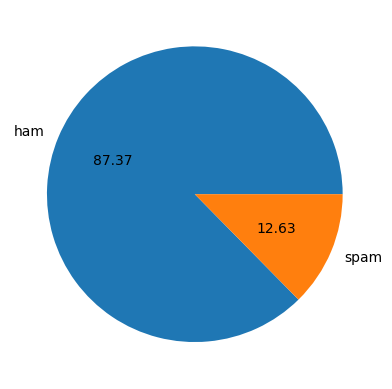

In [23]:
plt.pie(df["Target"].value_counts() , labels = ["ham" , "spam"] , autopct = "%0.2f")
plt.show()

In [24]:
# Data is imbalance

In [25]:
import nltk

In [26]:
nltk.download("punkt")

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\sajan\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [27]:
nltk

<module 'nltk' from 'C:\\Users\\sajan\\AppData\\Local\\Packages\\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\\LocalCache\\local-packages\\Python312\\site-packages\\nltk\\__init__.py'>

In [28]:
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\sajan\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\sajan\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [29]:
df["text"].apply(len)

0       111
1        29
2       155
3        49
4        61
       ... 
5567    161
5568     37
5569     57
5570    125
5571     26
Name: text, Length: 5169, dtype: int64

In [30]:
df["num_characters"] = df["text"].apply(len)

C:\Users\sajan\AppData\Local\Temp\ipykernel_3724\2250809779.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["num_characters"] = df["text"].apply(len)


In [31]:
df.sample(5)

,Target,text,num_characters
2067,0,Who's there say hi to our drugdealer,36
3019,0,I thank you so much for all you do with selfle...,72
32,0,K tell me anything about you.,29
228,0,Life is more strict than teacher... Bcoz Teach...,165
3435,0,If india win or level series means this is rec...,51


In [32]:
df["text"].apply(lambda x : nltk.word_tokenize(x)) # nltk.word_tokenize() breaks a sentence into words.

0       [Go, until, jurong, point, ,, crazy, .., Avail...
1                [Ok, lar, ..., Joking, wif, u, oni, ...]
2       [Free, entry, in, 2, a, wkly, comp, to, win, F...
3       [U, dun, say, so, early, hor, ..., U, c, alrea...
4       [Nah, I, do, n't, think, he, goes, to, usf, ,,...
                              ...                        
5567    [This, is, the, 2nd, time, we, have, tried, 2,...
5568     [Will, Ì_, b, going, to, esplanade, fr, home, ?]
5569    [Pity, ,, *, was, in, mood, for, that, ., So, ...
5570    [The, guy, did, some, bitching, but, I, acted,...
5571                  [Rofl, ., Its, true, to, its, name]
Name: text, Length: 5169, dtype: object

In [33]:
df["text"].apply(lambda x : len(nltk.word_tokenize(x))) # Now checking how much word len

0       24
1        8
2       37
3       13
4       15
        ..
5567    35
5568     9
5569    15
5570    27
5571     7
Name: text, Length: 5169, dtype: int64

In [34]:
df["num_words"] = df["text"].apply(lambda x : len(nltk.word_tokenize(x))) 

C:\Users\sajan\AppData\Local\Temp\ipykernel_3724\3851656211.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["num_words"] = df["text"].apply(lambda x : len(nltk.word_tokenize(x)))


In [35]:
 df["text"].apply(lambda x :nltk.sent_tokenize(x)) # nltk.sent_tokenize() breaks a paragraph into sentences.

0       [Go until jurong point, crazy.., Available onl...
1                        [Ok lar..., Joking wif u oni...]
2       [Free entry in 2 a wkly comp to win FA Cup fin...
3       [U dun say so early hor... U c already then sa...
4       [Nah I don't think he goes to usf, he lives ar...
                              ...                        
5567    [This is the 2nd time we have tried 2 contact ...
5568              [Will Ì_ b going to esplanade fr home?]
5569    [Pity, * was in mood for that., So...any other...
5570    [The guy did some bitching but I acted like i'...
5571                        [Rofl., Its true to its name]
Name: text, Length: 5169, dtype: object

In [36]:
df["num_sentences"] =  df["text"].apply(lambda x :len(nltk.sent_tokenize(x)) )

C:\Users\sajan\AppData\Local\Temp\ipykernel_3724\1192111294.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["num_sentences"] =  df["text"].apply(lambda x :len(nltk.sent_tokenize(x)) )


In [37]:
df.sample(9)

,Target,text,num_characters,num_words,num_sentences
3765,0,Yes.mum lookin strong:),23,5,1
4962,0,I want to see your pretty pussy...,34,8,1
2972,0,Happy New Year Princess!,24,5,1
313,0,"Hi the way I was with u 2day, is the normal wa...",142,41,3
2707,1,Great NEW Offer - DOUBLE Mins & DOUBLE Txt on ...,160,33,3
4765,0,Whens your radio show?,22,5,1
2538,0,The monthly amount is not that terrible and yo...,106,19,1
3303,0,IM GONNAMISSU SO MUCH!!I WOULD SAY IL SEND U A...,153,31,3
4944,0,Anyway I don't think I can secure anything up ...,107,25,1


In [38]:
df.head()

,Target,text,num_characters,num_words,num_sentences
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1


In [39]:
df.columns

Index(['Target', 'text', 'num_characters', 'num_words', 'num_sentences'], dtype='object')

In [40]:
df[['num_characters', 'num_words', 'num_sentences']].describe()

,num_characters,num_words,num_sentences
count,5169.000000,5169.000000,5169.000000
mean,78.977945,18.455794,1.965564
std,58.236293,13.324758,1.448541
min,2.000000,1.000000,1.000000
25%,36.000000,9.000000,1.000000
50%,60.000000,15.000000,1.000000
75%,117.000000,26.000000,2.000000
max,910.000000,220.000000,38.000000


In [41]:
# Only ham msg
df[df["Target"] == 0][['num_characters', 'num_words', 'num_sentences']].describe()

,num_characters,num_words,num_sentences
count,4516.000000,4516.000000,4516.000000
mean,70.459256,17.123782,1.820195
std,56.358207,13.493970,1.383657
min,2.000000,1.000000,1.000000
25%,34.000000,8.000000,1.000000
50%,52.000000,13.000000,1.000000
75%,90.000000,22.000000,2.000000
max,910.000000,220.000000,38.000000


In [42]:
# Only spam msg
df[df["Target"] == 1][['num_characters', 'num_words', 'num_sentences']].describe()

,num_characters,num_words,num_sentences
count,653.000000,653.000000,653.000000
mean,137.891271,27.667688,2.970904
std,30.137753,7.008418,1.488425
min,13.000000,2.000000,1.000000
25%,132.000000,25.000000,2.000000
50%,149.000000,29.000000,3.000000
75%,157.000000,32.000000,4.000000
max,224.000000,46.000000,9.000000


<Axes: xlabel='num_characters', ylabel='Count'>

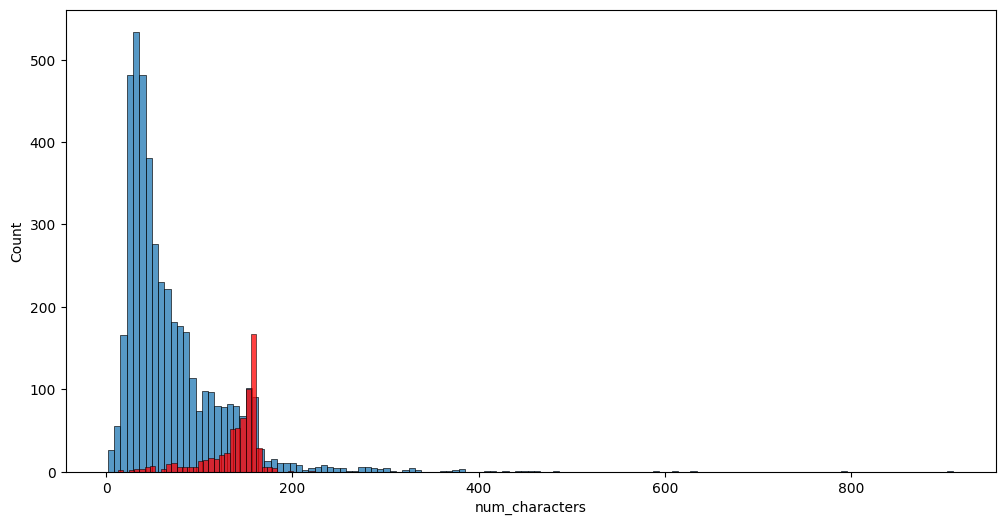

In [43]:
plt.figure(figsize = (12 , 6))
sns.histplot(df[df["Target"] == 0]['num_characters']) # ham
sns.histplot(df[df["Target"] == 1]['num_characters'] , color  = "red") # spam

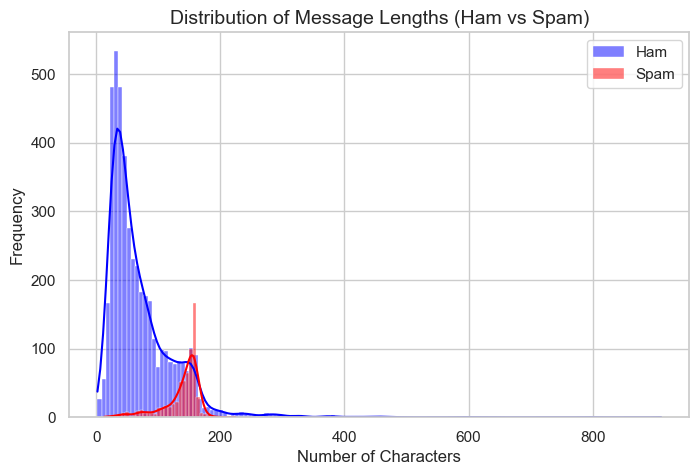

In [44]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.set(style="whitegrid")

# Plot
plt.figure(figsize=(8, 5))
sns.histplot(df[df["Target"] == 0]["num_characters"], color="blue", label="Ham", kde=True)
sns.histplot(df[df["Target"] == 1]["num_characters"], color="red", label="Spam", kde=True)

# Labels and title
plt.title("Distribution of Message Lengths (Ham vs Spam)", fontsize=14)
plt.xlabel("Number of Characters")
plt.ylabel("Frequency")
plt.legend()
plt.show()


C:\Users\sajan\AppData\Local\Temp\ipykernel_3724\1465297546.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x="Target", y="num_characters", data=df, palette=["skyblue", "lightcoral"], estimator="mean", ci=None)
C:\Users\sajan\AppData\Local\Temp\ipykernel_3724\1465297546.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Target", y="num_characters", data=df, palette=["skyblue", "lightcoral"], estimator="mean", ci=None)


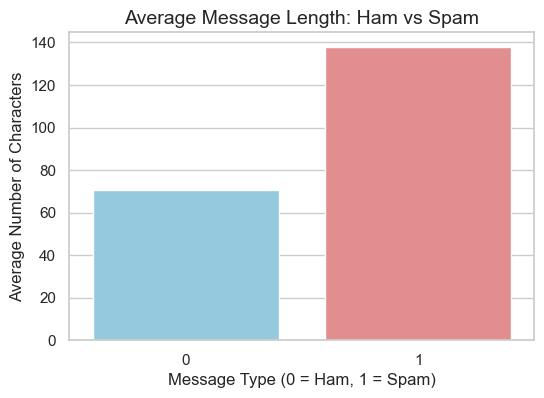

In [45]:
plt.figure(figsize=(6,4))
sns.barplot(x="Target", y="num_characters", data=df, palette=["skyblue", "lightcoral"], estimator="mean", ci=None)
plt.title("Average Message Length: Ham vs Spam", fontsize=14)
plt.xlabel("Message Type (0 = Ham, 1 = Spam)")
plt.ylabel("Average Number of Characters")
plt.show()


<Axes: xlabel='num_words', ylabel='Count'>

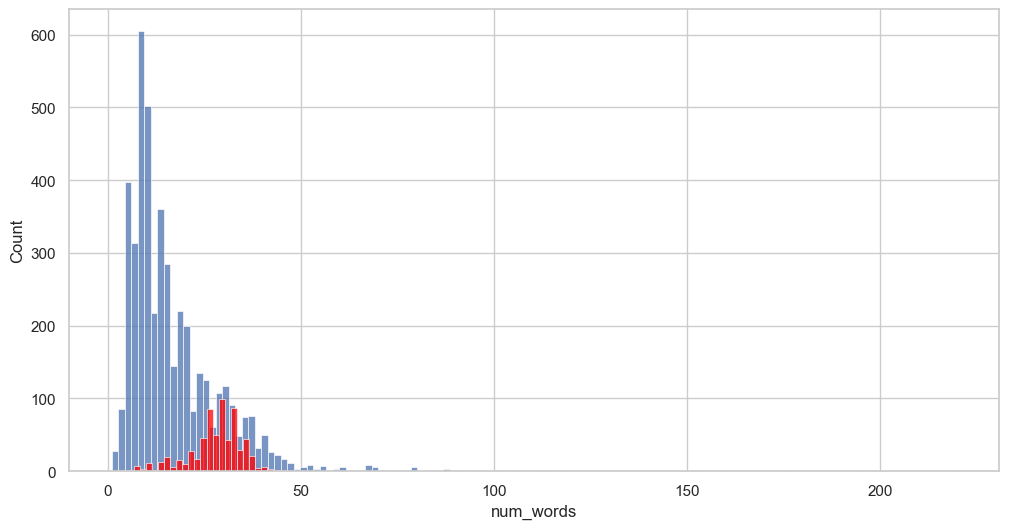

In [46]:
plt.figure(figsize = (12 , 6))
sns.histplot(df[df["Target"] == 0]['num_words']) # ham
sns.histplot(df[df["Target"] == 1]['num_words'] , color  = "red") # spam

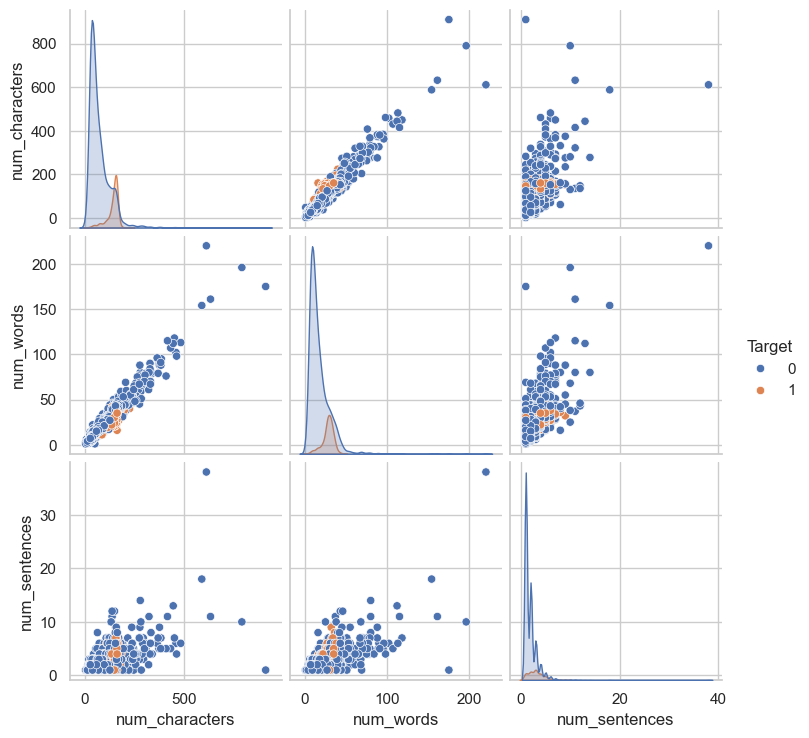

In [47]:
sns.pairplot(df , hue = "Target")

C:\Users\sajan\AppData\Local\Temp\ipykernel_3724\3161691037.py:20: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\sajan\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


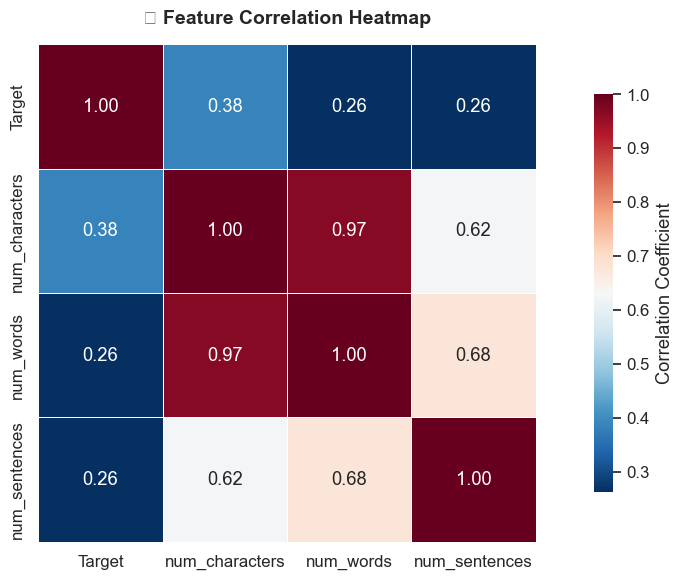

In [48]:

# Set clean visual theme
sns.set_theme(style="white", font_scale=1.1)

# Calculate correlation matrix
corr = df.corr(numeric_only=True)

# Create the heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(
    corr,
    annot=True,
    cmap="RdBu_r",
    fmt=".2f",
    linewidths=0.5,
    square=True,
    cbar_kws={"shrink": 0.8, "label": "Correlation Coefficient"}
)

plt.title("📈 Feature Correlation Heatmap", fontsize=14, fontweight="bold", pad=15)
plt.tight_layout()
plt.show()


In [49]:
# text preprocessing

## 3)🧹 **Data Preprocessing Steps**

1. **Convert to Lowercase**  
   Convert all text to lowercase to ensure uniformity and avoid treating words like *Spam* and *spam* as different.

2. **Tokenization**  
   Split sentences into individual words or tokens for easier analysis.

3. **Removing Special Characters**  
   Eliminate symbols, numbers, and unwanted characters that don’t add meaning to the text.

4. **Removing Stopwords and Punctuation**  
   Remove common words (like *is*, *the*, *and*) and punctuation marks that don’t contribute to the context.

5. **Stemming**  
   Reduce words to their root form (e.g., *running* → *run*, *studies* → *study*) to normalize variations.


### 🔤 **Example: Stemming in Action**

| **Original Words**              | **After Stemming** |
|---------------------------------|--------------------|
| playing, played, plays          | play               |
| studying, studies, studied      | studi              |
| running, runner, runs           | run                |


In [50]:
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\sajan\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [51]:
import string
string.punctuation

'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

In [52]:
from nltk.corpus import stopwords
stopwords.words("english")  # Checks all stopwords and means no contribution in sentece 

['a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 'her',
 'here',
 'hers',
 'herself',
 "he's",
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 'if',
 "i'll",
 "i'm",
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 "i've",
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'on

In [53]:
from nltk.stem import PorterStemmer
ps = PorterStemmer()
ps.stem("going")

'go'

In [54]:
def transform_text(text):
    text = text.lower()
    text = nltk.word_tokenize(text)

    y = []

    for i in text:   ##remnoves spesial Character ex % ?
        if i.isalnum():
            y.append(i)

        text = y[:] # Copy in the list
        y.clear()

        for i in text:
            if i not in stopwords.words("english") and i not in string.punctuation:
                y.append(i)

        text = y[:]
        y.clear()

        for i in text:
            y.append(ps.stem(i))
    return " ".join(y)

In [55]:
transform_text("I'm gonna be home soon and i don't want to talk about this stuff anymore tonight, k? I've cried enough today.")

'gon na home soon want talk stuff anymor tonight k cri enough today'

In [56]:
df["text"][10]

"I'm gonna be home soon and i don't want to talk about this stuff anymore tonight, k? I've cried enough today."

In [57]:
# df["text"].apply(transform_text)

In [58]:
# df["transformed_textx"] =  df["text"].apply(transform_text)

In [59]:
# logical steps (lower → tokenize → clean → stem → join)

import nltk
import string
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from tqdm import tqdm

# Download required resources once
nltk.download('punkt')
nltk.download('stopwords')

# Initialize heavy objects once (outside function)
ps = PorterStemmer()
stop_words = set(stopwords.words('english'))

# Enable progress bar
tqdm.pandas()

def transform_text(text):
    # 1️⃣ Lowercase
    text = text.lower()

    # 2️⃣ Tokenize
    words = nltk.word_tokenize(text)

    # 3️⃣ Keep only alphanumeric words
    words = [word for word in words if word.isalnum()]

    # 4️⃣ Remove stopwords and punctuation
    words = [word for word in words if word not in stop_words and word not in string.punctuation]

    # 5️⃣ Stemming
    words = [ps.stem(word) for word in words]

    # 6️⃣ Join back to string
    return " ".join(words)


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\sajan\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\sajan\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [60]:
# Apply with progress bar
df["transformed_textx"] = df["text"].progress_apply(transform_text)

100%|████████████████████████████████████████████████████████████████████████████| 5169/5169 [00:00<00:00, 6573.16it/s]
C:\Users\sajan\AppData\Local\Temp\ipykernel_3724\1105568930.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["transformed_textx"] = df["text"].progress_apply(transform_text)


In [61]:
df

,Target,text,num_characters,num_words,num_sentences,transformed_textx
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though
...,...,...,...,...,...,...
5567,1,This is the 2nd time we have tried 2 contact u...,161,35,4,2nd time tri 2 contact u pound prize 2 claim e...
5568,0,Will Ì_ b going to esplanade fr home?,37,9,1,b go esplanad fr home
5569,0,"Pity, * was in mood for that. So...any other s...",57,15,2,piti mood suggest
5570,0,The guy did some bitching but I acted like i'd...,125,27,1,guy bitch act like interest buy someth els nex...


In [62]:
df[["text" , "transformed_textx"]]

,text,transformed_textx
0,"Go until jurong point, crazy.. Available only ...",go jurong point crazi avail bugi n great world...
1,Ok lar... Joking wif u oni...,ok lar joke wif u oni
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entri 2 wkli comp win fa cup final tkt 21...
3,U dun say so early hor... U c already then say...,u dun say earli hor u c alreadi say
4,"Nah I don't think he goes to usf, he lives aro...",nah think goe usf live around though
...,...,...
5567,This is the 2nd time we have tried 2 contact u...,2nd time tri 2 contact u pound prize 2 claim e...
5568,Will Ì_ b going to esplanade fr home?,b go esplanad fr home
5569,"Pity, * was in mood for that. So...any other s...",piti mood suggest
5570,The guy did some bitching but I acted like i'd...,guy bitch act like interest buy someth els nex...


In [63]:
df["text"][0]

'Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...'

In [64]:
df["transformed_textx"][0]

'go jurong point crazi avail bugi n great world la e buffet cine got amor wat'

In [65]:
from wordcloud import WordCloud
wc  = WordCloud(width = 1000 , height = 1000 , min_font_size = 10 , background_color = "white"  )

In [66]:
spam_wc = wc.generate(df[df["Target"] == 1]["transformed_textx"].str.cat(sep = " "))

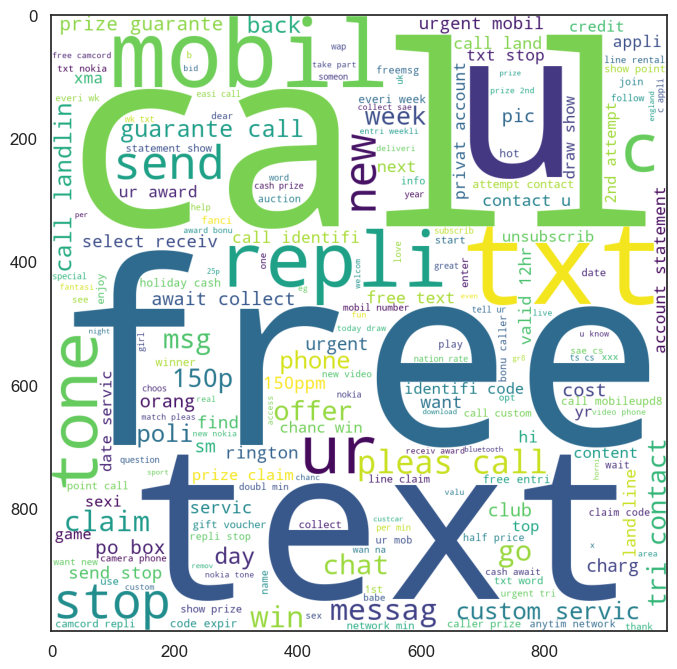

In [67]:
plt.figure(figsize = (16 ,8))
plt.imshow(spam_wc)

In [68]:
ham_wc = wc.generate(df[df["Target"] == 0]["transformed_textx"].str.cat(sep = " "))

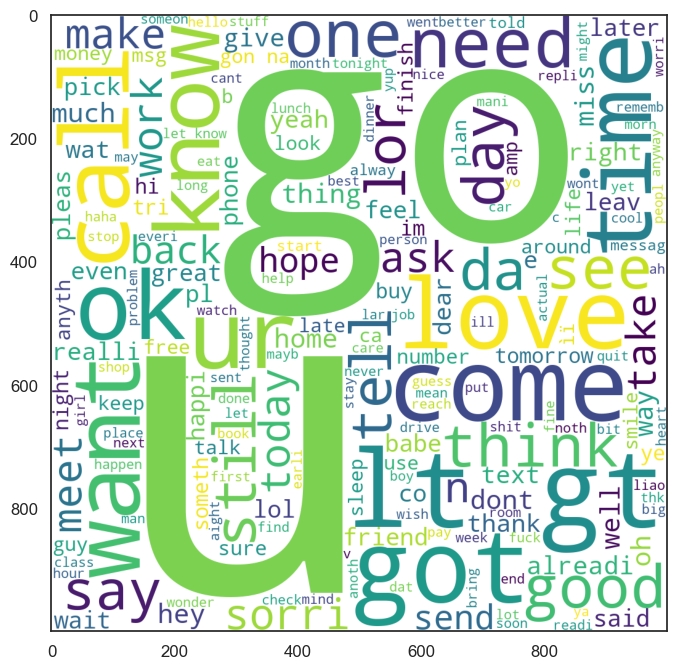

In [69]:
plt.figure(figsize = (16 ,8))
plt.imshow(ham_wc)

In [70]:
df.head()

,Target,text,num_characters,num_words,num_sentences,transformed_textx
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


In [71]:
spam_corpus = []
for msg in df[df["Target"] == 1]["transformed_textx"].tolist(): # All Spam Massage
    for word in msg.split():
        spam_corpus.append(word)

In [72]:
spam_corpus # spam words

['free',
 'entri',
 '2',
 'wkli',
 'comp',
 'win',
 'fa',
 'cup',
 'final',
 'tkt',
 '21st',
 'may',
 'text',
 'fa',
 '87121',
 'receiv',
 'entri',
 'question',
 'std',
 'txt',
 'rate',
 'c',
 'appli',
 '08452810075over18',
 'freemsg',
 'hey',
 'darl',
 '3',
 'week',
 'word',
 'back',
 'like',
 'fun',
 'still',
 'tb',
 'ok',
 'xxx',
 'std',
 'chg',
 'send',
 'rcv',
 'winner',
 'valu',
 'network',
 'custom',
 'select',
 'receivea',
 'prize',
 'reward',
 'claim',
 'call',
 'claim',
 'code',
 'kl341',
 'valid',
 '12',
 'hour',
 'mobil',
 '11',
 'month',
 'u',
 'r',
 'entitl',
 'updat',
 'latest',
 'colour',
 'mobil',
 'camera',
 'free',
 'call',
 'mobil',
 'updat',
 'co',
 'free',
 '08002986030',
 'six',
 'chanc',
 'win',
 'cash',
 '100',
 'pound',
 'txt',
 'csh11',
 'send',
 'cost',
 '6day',
 'tsandc',
 'appli',
 'repli',
 'hl',
 '4',
 'info',
 'urgent',
 '1',
 'week',
 'free',
 'membership',
 'prize',
 'jackpot',
 'txt',
 'word',
 'claim',
 '81010',
 'c',
 'lccltd',
 'pobox',
 '4403ldnw

In [73]:
len(spam_corpus) # total spam words

9939

In [74]:
from collections import Counter

In [75]:
Counter(spam_corpus) # this check howch time each word ocuuer this will gives us aczat number  
# Counter(spam_corpus) → gives a word frequency dictionary (word → count).

Counter({'call': 320,
         'free': 191,
         '2': 155,
         'txt': 141,
         'text': 122,
         'u': 119,
         'ur': 119,
         'mobil': 114,
         'stop': 104,
         'repli': 103,
         'claim': 98,
         '4': 97,
         'prize': 82,
         'get': 74,
         'new': 64,
         'servic': 64,
         'tone': 63,
         'send': 60,
         'urgent': 57,
         'nokia': 57,
         'contact': 56,
         'award': 55,
         'phone': 52,
         'cash': 51,
         'pleas': 51,
         'week': 49,
         'win': 48,
         'c': 45,
         'collect': 45,
         'min': 45,
         'custom': 42,
         'messag': 42,
         'guarante': 42,
         'per': 41,
         'chat': 38,
         'tri': 37,
         'msg': 35,
         'draw': 35,
         'number': 35,
         'cs': 35,
         'show': 33,
         'today': 33,
         'offer': 33,
         'line': 33,
         'go': 32,
         'receiv': 31,
         'want': 3

In [76]:
Counter(spam_corpus).most_common(30)  # most COmmon #0 words wioth frq

[('call', 320),
 ('free', 191),
 ('2', 155),
 ('txt', 141),
 ('text', 122),
 ('u', 119),
 ('ur', 119),
 ('mobil', 114),
 ('stop', 104),
 ('repli', 103),
 ('claim', 98),
 ('4', 97),
 ('prize', 82),
 ('get', 74),
 ('new', 64),
 ('servic', 64),
 ('tone', 63),
 ('send', 60),
 ('urgent', 57),
 ('nokia', 57),
 ('contact', 56),
 ('award', 55),
 ('phone', 52),
 ('cash', 51),
 ('pleas', 51),
 ('week', 49),
 ('win', 48),
 ('c', 45),
 ('collect', 45),
 ('min', 45)]

C:\Users\sajan\AppData\Local\Temp\ipykernel_3724\1873848603.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Word', y='Frequency', data=common_words, palette='coolwarm')


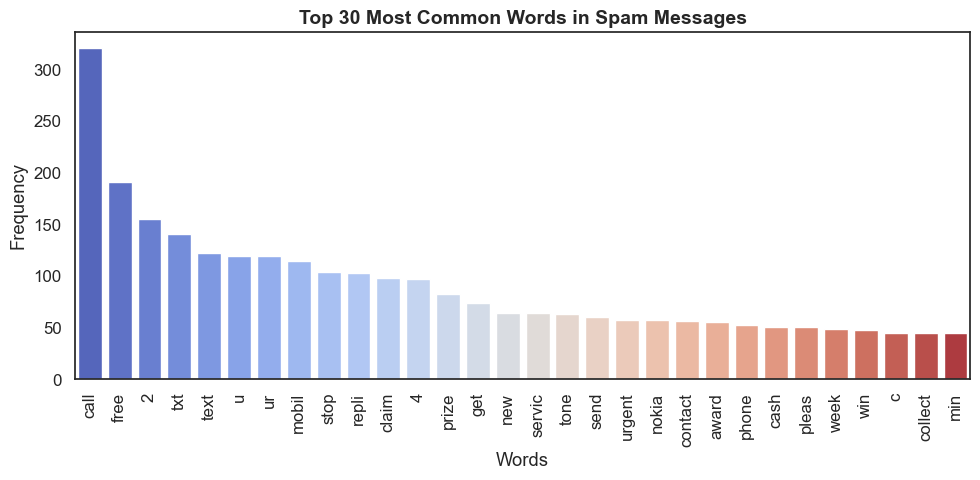

In [77]:
# Count top 30 most common words in spam messages
common_words = pd.DataFrame(Counter(spam_corpus).most_common(30), columns=['Word', 'Frequency'])

# Plot
plt.figure(figsize=(10, 5))
sns.barplot(x='Word', y='Frequency', data=common_words, palette='coolwarm')

# Style
plt.xticks(rotation='vertical')
plt.title("Top 30 Most Common Words in Spam Messages", fontsize=14, fontweight="bold")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

In [78]:
# For Ham

In [79]:
ham_corpus = []
for msg in df[df["Target"] == 0]["transformed_textx"].tolist(): # All Spam Massage
    for word in msg.split():
        ham_corpus.append(word)

In [80]:
ham_corpus

['go',
 'jurong',
 'point',
 'crazi',
 'avail',
 'bugi',
 'n',
 'great',
 'world',
 'la',
 'e',
 'buffet',
 'cine',
 'got',
 'amor',
 'wat',
 'ok',
 'lar',
 'joke',
 'wif',
 'u',
 'oni',
 'u',
 'dun',
 'say',
 'earli',
 'hor',
 'u',
 'c',
 'alreadi',
 'say',
 'nah',
 'think',
 'goe',
 'usf',
 'live',
 'around',
 'though',
 'even',
 'brother',
 'like',
 'speak',
 'treat',
 'like',
 'aid',
 'patent',
 'per',
 'request',
 'mell',
 'oru',
 'minnaminungint',
 'nurungu',
 'vettam',
 'set',
 'callertun',
 'caller',
 'press',
 '9',
 'copi',
 'friend',
 'callertun',
 'gon',
 'na',
 'home',
 'soon',
 'want',
 'talk',
 'stuff',
 'anymor',
 'tonight',
 'k',
 'cri',
 'enough',
 'today',
 'search',
 'right',
 'word',
 'thank',
 'breather',
 'promis',
 'wont',
 'take',
 'help',
 'grant',
 'fulfil',
 'promis',
 'wonder',
 'bless',
 'time',
 'date',
 'sunday',
 'oh',
 'k',
 'watch',
 'eh',
 'u',
 'rememb',
 '2',
 'spell',
 'name',
 'ye',
 'v',
 'naughti',
 'make',
 'v',
 'wet',
 'fine',
 'thatåõ',
 'wa

In [81]:
len(ham_corpus) # total spam words

35404

In [82]:
Counter(ham_corpus) 

Counter({'u': 883,
         'go': 404,
         'get': 349,
         'gt': 288,
         'lt': 287,
         '2': 284,
         'come': 275,
         'got': 236,
         'know': 236,
         'like': 234,
         'call': 233,
         'time': 219,
         'ok': 217,
         'love': 216,
         'good': 213,
         'want': 208,
         'ur': 197,
         'day': 190,
         'need': 170,
         'one': 165,
         'lor': 159,
         '4': 156,
         'home': 152,
         'think': 149,
         'see': 147,
         'take': 143,
         'still': 143,
         'da': 142,
         'tell': 133,
         'make': 129,
         'say': 127,
         'back': 127,
         'today': 123,
         'hope': 122,
         'ask': 121,
         'sorri': 121,
         'n': 120,
         'send': 120,
         'r': 120,
         'work': 118,
         'dont': 118,
         'meet': 112,
         'hi': 111,
         'well': 109,
         'thing': 109,
         'wat': 108,
         'k': 107,
  

C:\Users\sajan\AppData\Local\Temp\ipykernel_3724\4084571885.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Word', y='Frequency', data=common_words, palette='coolwarm')


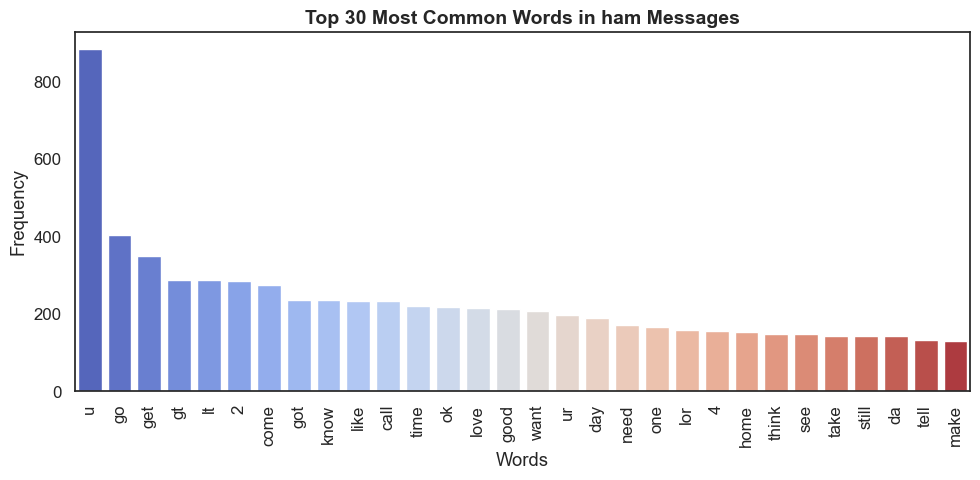

In [83]:
# Count top 30 most common words in spam messages
common_words = pd.DataFrame(Counter(ham_corpus).most_common(30), columns=['Word', 'Frequency'])

# Plot
plt.figure(figsize=(10, 5))
sns.barplot(x='Word', y='Frequency', data=common_words, palette='coolwarm')

# Style
plt.xticks(rotation='vertical')
plt.title("Top 30 Most Common Words in ham Messages", fontsize=14, fontweight="bold")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

### **4. Model Building**

In [84]:
# navi bias based algo beacuse it works good on textual data

In [85]:
# 👉 Naive Bayes (often written as Naïve Bayes) is one of the best algorithms for text data, 
# especially for tasks like spam detection, sentiment analysis, and document classification.

In [86]:
from sklearn.feature_extraction.text import CountVectorizer,TfidfVectorizer

In [87]:
cv= CountVectorizer()

In [88]:
tfidf = TfidfVectorizer()

In [89]:
X = cv.fit_transform(df["transformed_textx"]).toarray()

In [90]:
X.shape

(5169, 6708)

In [91]:
y = df["Target"].values

In [92]:
y

array([0, 0, 1, ..., 0, 0, 0], shape=(5169,))

In [93]:
from sklearn.model_selection import train_test_split

In [94]:
X_train , X_test , y_train , y_test = train_test_split(X , y , test_size = 0.2 , random_state = 2)

In [95]:
from sklearn.naive_bayes import GaussianNB,MultinomialNB,BernoulliNB
from sklearn.metrics import accuracy_score,confusion_matrix,precision_score

In [96]:
gnb = GaussianNB()
mnb = MultinomialNB()
bnb = BernoulliNB()

In [97]:
gnb.fit(X_train,y_train)
y_pred1 = gnb.predict(X_test)
print(accuracy_score(y_test,y_pred1))
print(confusion_matrix(y_test,y_pred1))
print(precision_score(y_test,y_pred1))

0.8800773694390716
[[792 104]
 [ 20 118]]
0.5315315315315315


In [98]:
print("📊 Gaussian Naive Bayes Results")
print("-" * 35)
print(f"✅ Accuracy  : {accuracy_score(y_test, y_pred1):.4f}")
print(f"🎯 Precision : {precision_score(y_test, y_pred1):.4f}")
print("🧩 Confusion Matrix:")
print(confusion_matrix(y_test, y_pred1))

📊 Gaussian Naive Bayes Results
-----------------------------------
✅ Accuracy  : 0.8801
🎯 Precision : 0.5315
🧩 Confusion Matrix:
[[792 104]
 [ 20 118]]


In [99]:
mnb.fit(X_train,y_train)
y_pred2 = mnb.predict(X_test)
print(accuracy_score(y_test,y_pred2))
print(confusion_matrix(y_test,y_pred2))
print(precision_score(y_test,y_pred2))

0.9642166344294004
[[871  25]
 [ 12 126]]
0.8344370860927153


In [100]:
bnb.fit(X_train,y_train)
y_pred3 = bnb.predict(X_test)
print(accuracy_score(y_test,y_pred3))
print(confusion_matrix(y_test,y_pred3))
print(precision_score(y_test,y_pred3))

0.9700193423597679
[[893   3]
 [ 28 110]]
0.9734513274336283


## **Using  TfidfVectorizer**

In [101]:
# X = tfidf.fit_transform(df["transformed_textx"]).toarray()

In [102]:
# y = df["Target"].values

In [103]:
# from sklearn.model_selection import train_test_split

In [104]:
# X_train , X_test , y_train , y_test = train_test_split(X , y , test_size = 0.2 , random_state = 2)

In [105]:
df

,Target,text,num_characters,num_words,num_sentences,transformed_textx
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though
...,...,...,...,...,...,...
5567,1,This is the 2nd time we have tried 2 contact u...,161,35,4,2nd time tri 2 contact u pound prize 2 claim e...
5568,0,Will Ì_ b going to esplanade fr home?,37,9,1,b go esplanad fr home
5569,0,"Pity, * was in mood for that. So...any other s...",57,15,2,piti mood suggest
5570,0,The guy did some bitching but I acted like i'd...,125,27,1,guy bitch act like interest buy someth els nex...


In [106]:
X_text = df['transformed_textx']

In [107]:
y = df['Target'].values

In [108]:
X_train_text, X_test_text, y_train, y_test = train_test_split(X_text, y, test_size=0.2, random_state=2)

In [109]:
X_train = tfidf.fit_transform(X_train_text).toarray()

In [110]:
from sklearn.naive_bayes import GaussianNB,MultinomialNB,BernoulliNB
from sklearn.metrics import accuracy_score,confusion_matrix,precision_score

In [111]:
X_test = tfidf.transform(X_test_text).toarray()

In [112]:
gnb = GaussianNB()
mnb = MultinomialNB()
bnb = BernoulliNB()

In [113]:
gnb.fit(X_train,y_train)
y_pred1 = gnb.predict(X_test)
print(accuracy_score(y_test,y_pred1))
print(confusion_matrix(y_test,y_pred1))
print(precision_score(y_test,y_pred1))

0.8752417794970987
[[792 104]
 [ 25 113]]
0.5207373271889401


In [114]:

mnb.fit(X_train,y_train)
y_pred2 = mnb.predict(X_test)
print(accuracy_score(y_test,y_pred2))
print(confusion_matrix(y_test,y_pred2))
print(precision_score(y_test,y_pred2))

0.9584139264990329
[[896   0]
 [ 43  95]]
1.0


# 📝 Model Performance Analysis: Multinomial Naive Bayes (MNB)

This analysis is based on the provided evaluation metrics and Confusion Matrix for the MNB model.

---

## 📊 Evaluation Metrics Summary

| Metric | Value | Interpretation |
| :--- | :--- | :--- |
| **Accuracy Score** | $0.9594$ (approx. **$95.94\%$**) | The proportion of total predictions that were correct (both positive and negative). |
| **Precision Score** | $1.0$ (**$100\%$**) | The proportion of **positive predictions** that were actually correct. |

---

## 🔍 Confusion Matrix Breakdown

The Confusion Matrix structure and values are:

$$
\begin{pmatrix}
\text{TN} & \text{FP} \\
\text{FN} & \text{TP}
\end{pmatrix}
=
\begin{pmatrix}
896 & 0 \\
42 & 96
\end{pmatrix}
$$

| Metric | Count | Description |
| :--- | :--- | :--- |
| **True Negative (TN)** | $896$ | Correctly classified the negative class. |
| **False Positive (FP)** | **$0$** | **Incorrectly predicted the positive class (Type I Error).** |
| **False Negative (FN)** | $42$ | Incorrectly predicted the negative class (Type II Error). |
| **True Positive (TP)** | $96$ | Correctly classified the positive class. |

---

## 💡 Interpretation and Key Note

### 🎯 Key Observation: Perfect Precision

The most significant result is the **Precision Score of $1.0$ (or $100\%$ precision)**.

* Precision is calculated as $\frac{TP}{TP + FP}$. Since the number of **False Positives (FP) is $\mathbf{0}$**, the model achieved perfect precision.
* **Meaning:** When the model predicts an instance belongs to the positive class (e.g., "Spam"), it is **always correct**. It did not make a single mistake by flagging a true negative instance as positive. This is highly desirable in scenarios where **False Positives are costly** (e.g., ensuring a genuine email is never flagged as spam).

### 📉 Accuracy vs. False Negatives

* The overall **Accuracy is high** but slightly less than $100\%$ ($\approx 95.94\%$) because of the **$42$ False Negatives (FN)**.
* **Meaning:** The model failed to identify $42$ instances of the actual positive class, mistakenly classifying them as negative.
* **Trade-off:** The model has traded a small amount of overall accuracy and **Recall** (the ability to find all positive cases) for the assurance of **$100\%$ Precision**. It is extremely conservative in making a positive prediction, which eliminates FPs but results in some FNs.

> **Conclusion:** **The MNB model is a very strong and trustworthy classifier for its positive predictions, showing perfect Precision ($1.0$). While it is excellent at avoiding False Positives (FP=0), its ability to capture *all* positive cases (Recall) is slightly lower due to the 42 False Negatives, which ultimately pulls the overall Accuracy down slightly from a perfect score.**

In [115]:


bnb.fit(X_train,y_train)
y_pred3 = bnb.predict(X_test)
print(accuracy_score(y_test,y_pred3))
print(confusion_matrix(y_test,y_pred3))
print(precision_score(y_test,y_pred3))

0.965183752417795
[[896   0]
 [ 36 102]]
1.0


## **Tfid --> mnb**

In [116]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier

In [117]:
svc = SVC(kernel='sigmoid', gamma=1.0)
knc = KNeighborsClassifier()
mnb = MultinomialNB()
dtc = DecisionTreeClassifier(max_depth=5)
lrc = LogisticRegression(solver='liblinear', penalty='l1')
rfc = RandomForestClassifier(n_estimators=50, random_state=2)
abc = AdaBoostClassifier(n_estimators=50, random_state=2)
bc = BaggingClassifier(n_estimators=50, random_state=2)
etc = ExtraTreesClassifier(n_estimators=50, random_state=2)
gbdt = GradientBoostingClassifier(n_estimators=50,random_state=2)
xgb = XGBClassifier(n_estimators=50,random_state=2)

In [118]:
clfs = {
    'SVC' : svc,
    'KN' : knc, 
    'NB': mnb, 
    'DT': dtc, 
    'LR': lrc, 
    'RF': rfc, 
    'AdaBoost': abc, 
    'BgC': bc, 
    'ETC': etc,
    'GBDT':gbdt,
    'xgb':xgb
}

In [119]:
def train_classifier(clf,X_train,y_train,X_test,y_test):
    clf.fit(X_train,y_train)
    y_pred = clf.predict(X_test)
    accuracy = accuracy_score(y_test,y_pred)
    precision = precision_score(y_test,y_pred)
    
    return accuracy,precision

In [120]:

accuracy_scores = []
precision_scores = []

for name,clf in clfs.items():
    
    current_accuracy,current_precision = train_classifier(clf, X_train,y_train,X_test,y_test)
    
    print("For ",name)
    print("Accuracy - ",current_accuracy)
    print("Precision - ",current_precision)
    
    accuracy_scores.append(current_accuracy)
    precision_scores.append(current_precision)

For  SVC
Accuracy -  0.9796905222437138
Precision -  0.975609756097561
For  KN
Accuracy -  0.9052224371373307
Precision -  1.0
For  NB
Accuracy -  0.9584139264990329
Precision -  1.0
For  DT
Accuracy -  0.9313346228239845
Precision -  0.845360824742268
For  LR
Accuracy -  0.9555125725338491
Precision -  0.9339622641509434
For  RF
Accuracy -  0.9729206963249516
Precision -  0.9910714285714286
For  AdaBoost
Accuracy -  0.9245647969052224
Precision -  0.8571428571428571
For  BgC
Accuracy -  0.9555125725338491
Precision -  0.8709677419354839
For  ETC
Accuracy -  0.97678916827853
Precision -  0.975
For  GBDT
Accuracy -  0.9516441005802708
Precision -  0.94
For  xgb
Accuracy -  0.9690522243713733
Precision -  0.9491525423728814


In [121]:
performance_df = pd.DataFrame({'Algorithm':clfs.keys(),'Accuracy':accuracy_scores,'Precision':precision_scores}).sort_values('Precision',ascending=False)

In [122]:
performance_df

,Algorithm,Accuracy,Precision
1,KN,0.905222,1.000000
2,NB,0.958414,1.000000
5,RF,0.972921,0.991071
0,SVC,0.979691,0.975610
8,ETC,0.976789,0.975000
10,xgb,0.969052,0.949153
9,GBDT,0.951644,0.940000
4,LR,0.955513,0.933962
7,BgC,0.955513,0.870968
6,AdaBoost,0.924565,0.857143


In [123]:
performance_df = pd.DataFrame({
    'Algorithm': clfs.keys(),
    'Accuracy': accuracy_scores,
    'Precision': precision_scores
}).sort_values('Precision', ascending=False)


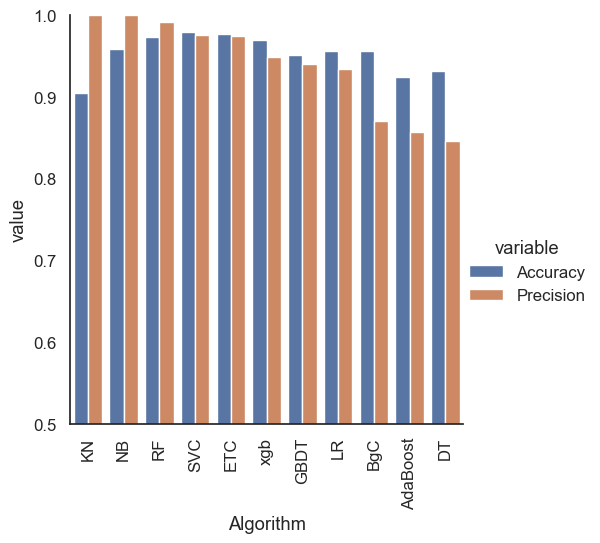

In [124]:

# Convert to long format for Seaborn
performance_df1 = pd.melt(performance_df, id_vars='Algorithm', 
                          var_name='variable', value_name='value')

# Plot
sns.catplot(
    x='Algorithm',
    y='value',
    hue='variable',
    data=performance_df1,
    kind='bar',
    height=5
)
plt.ylim(0.5, 1.0)
plt.xticks(rotation='vertical')
plt.show()


## **Model Improvenment**

In [125]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [126]:
tfidf = TfidfVectorizer(max_features=3000)

In [127]:
X = tfidf.fit_transform(df["transformed_textx"]).toarray()

In [128]:
y = df["Target"].values

In [129]:
X_train , X_test , y_train , y_test = train_test_split(X , y , test_size = 0.2 , random_state = 2)

In [130]:
gnb = GaussianNB()
mnb = MultinomialNB()
bnb = BernoulliNB()

In [131]:
gnb.fit(X_train,y_train)
y_pred1 = gnb.predict(X_test)
print(accuracy_score(y_test,y_pred1))
print(confusion_matrix(y_test,y_pred1))
print(precision_score(y_test,y_pred1))



0.874274661508704
[[790 106]
 [ 24 114]]
0.5181818181818182


In [132]:
mnb.fit(X_train,y_train)
y_pred2 = mnb.predict(X_test)
print(accuracy_score(y_test,y_pred2))
print(confusion_matrix(y_test,y_pred2))
print(precision_score(y_test,y_pred2))


0.9709864603481625
[[896   0]
 [ 30 108]]
1.0


In [133]:

bnb.fit(X_train,y_train)
y_pred3 = bnb.predict(X_test)
print(accuracy_score(y_test,y_pred3))
print(confusion_matrix(y_test,y_pred3))
print(precision_score(y_test,y_pred3))

0.9835589941972921
[[895   1]
 [ 16 122]]
0.991869918699187


In [134]:
svc = SVC(kernel='sigmoid', gamma=1.0)
knc = KNeighborsClassifier()
mnb = MultinomialNB()
dtc = DecisionTreeClassifier(max_depth=5)
lrc = LogisticRegression(solver='liblinear', penalty='l1')
rfc = RandomForestClassifier(n_estimators=50, random_state=2)
abc = AdaBoostClassifier(n_estimators=50, random_state=2)
bc = BaggingClassifier(n_estimators=50, random_state=2)
etc = ExtraTreesClassifier(n_estimators=50, random_state=2)
gbdt = GradientBoostingClassifier(n_estimators=50,random_state=2)
xgb = XGBClassifier(n_estimators=50,random_state=2)

In [135]:
clfs = {
    'SVC' : svc,
    'KN' : knc, 
    'NB': mnb, 
    'DT': dtc, 
    'LR': lrc, 
    'RF': rfc, 
    'AdaBoost': abc, 
    'BgC': bc, 
    'ETC': etc,
    'GBDT':gbdt,
    'xgb':xgb
}

In [136]:
def train_classifier(clf,X_train,y_train,X_test,y_test):
    clf.fit(X_train,y_train)
    y_pred = clf.predict(X_test)
    accuracy = accuracy_score(y_test,y_pred)
    precision = precision_score(y_test,y_pred)
    
    return accuracy,precision

In [137]:
%%time
accuracy_scores = []
precision_scores = []

for name,clf in clfs.items():
    
    current_accuracy,current_precision = train_classifier(clf, X_train,y_train,X_test,y_test)
    
    print("For ",name)
    print("Accuracy - ",current_accuracy)
    print("Precision - ",current_precision)
    
    accuracy_scores.append(current_accuracy)
    precision_scores.append(current_precision)

For  SVC
Accuracy -  0.9758220502901354
Precision -  0.9747899159663865
For  KN
Accuracy -  0.9052224371373307
Precision -  1.0
For  NB
Accuracy -  0.9709864603481625
Precision -  1.0
For  DT
Accuracy -  0.9332688588007737
Precision -  0.8415841584158416
For  LR
Accuracy -  0.9555125725338491
Precision -  0.96
For  RF
Accuracy -  0.9738878143133463
Precision -  0.9826086956521739
For  AdaBoost
Accuracy -  0.9216634429400387
Precision -  0.8202247191011236
For  BgC
Accuracy -  0.9584139264990329
Precision -  0.8682170542635659
For  ETC
Accuracy -  0.9748549323017408
Precision -  0.9745762711864406
For  GBDT
Accuracy -  0.9506769825918762
Precision -  0.9306930693069307
For  xgb
Accuracy -  0.9680851063829787
Precision -  0.9487179487179487
CPU times: total: 2min 34s
Wall time: 2min 21s


In [138]:
temp_df = pd.DataFrame({'Algorithm':clfs.keys(),'Accuracy_max_ft_3000':accuracy_scores,'Precision_max_ft_3000':precision_scores}).sort_values('Precision_max_ft_3000',ascending=False)

In [139]:
temp_df = pd.DataFrame({'Algorithm':clfs.keys(),'Accuracy_scaling':accuracy_scores,'Precision_scaling':precision_scores}).sort_values('Precision_scaling',ascending=False)

In [140]:
new_df = performance_df.merge(temp_df,on='Algorithm')

In [141]:
new_df_scaled = new_df.merge(temp_df,on='Algorithm')

In [142]:
temp_df = pd.DataFrame({'Algorithm':clfs.keys(),'Accuracy_num_chars':accuracy_scores,'Precision_num_chars':precision_scores}).sort_values('Precision_num_chars',ascending=False)

In [143]:
new_df_scaled.merge(temp_df,on='Algorithm')

,Algorithm,Accuracy,Precision,Accuracy_scaling_x,Precision_scaling_x,Accuracy_scaling_y,Precision_scaling_y,Accuracy_num_chars,Precision_num_chars
0,KN,0.905222,1.000000,0.905222,1.000000,0.905222,1.000000,0.905222,1.000000
1,NB,0.958414,1.000000,0.970986,1.000000,0.970986,1.000000,0.970986,1.000000
2,RF,0.972921,0.991071,0.973888,0.982609,0.973888,0.982609,0.973888,0.982609
3,SVC,0.979691,0.975610,0.975822,0.974790,0.975822,0.974790,0.975822,0.974790
4,ETC,0.976789,0.975000,0.974855,0.974576,0.974855,0.974576,0.974855,0.974576
5,xgb,0.969052,0.949153,0.968085,0.948718,0.968085,0.948718,0.968085,0.948718
6,GBDT,0.951644,0.940000,0.950677,0.930693,0.950677,0.930693,0.950677,0.930693
7,LR,0.955513,0.933962,0.955513,0.960000,0.955513,0.960000,0.955513,0.960000
8,BgC,0.955513,0.870968,0.958414,0.868217,0.958414,0.868217,0.958414,0.868217
9,AdaBoost,0.924565,0.857143,0.921663,0.820225,0.921663,0.820225,0.921663,0.820225


In [144]:
# Voting Classifier
svc = SVC(kernel='sigmoid', gamma=1.0,probability=True)
mnb = MultinomialNB()
etc = ExtraTreesClassifier(n_estimators=50, random_state=2)

from sklearn.ensemble import VotingClassifier

In [145]:
voting = VotingClassifier(estimators=[('svm', svc), ('nb', mnb), ('et', etc)],voting='soft')

In [146]:
voting.fit(X_train,y_train)

VotingClassifier(estimators=[('svm',
                              SVC(gamma=1.0, kernel='sigmoid',
                                  probability=True)),
                             ('nb', MultinomialNB()),
                             ('et',
                              ExtraTreesClassifier(n_estimators=50,
                                                   random_state=2))],
                 voting='soft')

In [147]:
y_pred = voting.predict(X_test)
print("Accuracy",accuracy_score(y_test,y_pred))
print("Precision",precision_score(y_test,y_pred))

Accuracy 0.9796905222437138
Precision 0.9834710743801653


In [148]:
# Applying stacking
estimators=[('svm', svc), ('nb', mnb), ('et', etc)]
final_estimator=RandomForestClassifier()

In [149]:
from sklearn.ensemble import StackingClassifier

In [150]:
clf = StackingClassifier(estimators=estimators, final_estimator=final_estimator)

In [151]:
clf.fit(X_train,y_train)
y_pred = clf.predict(X_test)
print("Accuracy",accuracy_score(y_test,y_pred))
print("Precision",precision_score(y_test,y_pred))

Accuracy 0.9787234042553191
Precision 0.9393939393939394


In [154]:
import pickle

mnb.fit(X_train, y_train)

pickle.dump(tfidf,open('vectorizer.pkl','wb'))
pickle.dump(mnb,open('model.pkl','wb'))

In [153]:
# Save your scaled DataFrame to CSV
new_df_scaled.to_csv("model Accnew_df_scaled.csv", index=False)